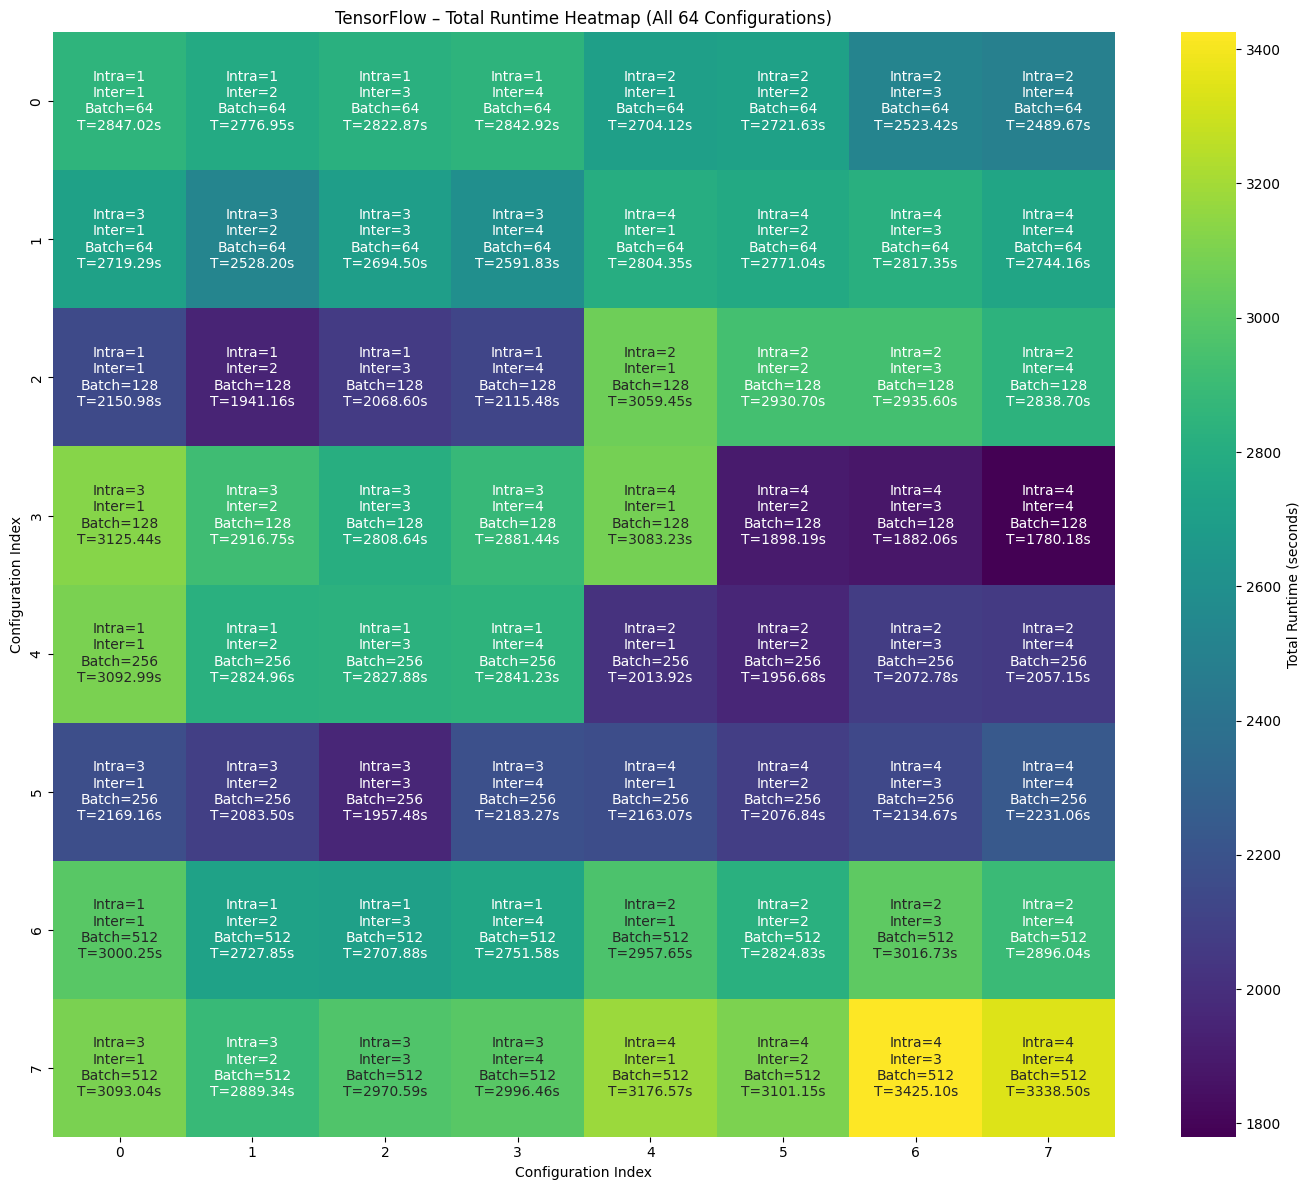

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


CSV_PATH = "/Users/akashsaha/Desktop/High-Performance-Computing/Heatmap/TensorFlow/Results/all_profiles_tf.csv"
df = pd.read_csv(CSV_PATH)


TOTAL_COL = "total_time"   
assert TOTAL_COL in df.columns, "total_time column not found in TF CSV"


agg = (
    df.groupby(
        ["intra_threads", "inter_threads", "batch_size"],
        as_index=False
    )[TOTAL_COL]
    .mean()
)

agg = agg.sort_values(
    by=["batch_size", "intra_threads", "inter_threads"]
).reset_index(drop=True)


assert len(agg) == 64, f"Expected 64 configs, got {len(agg)}"


heatmap_data = agg[TOTAL_COL].values.reshape(8, 8)

labels = agg.apply(
    lambda r: (
        f"Intra={int(r.intra_threads)}\n"
        f"Inter={int(r.inter_threads)}\n"
        f"Batch={int(r.batch_size)}\n"
        f"T={r[TOTAL_COL]:.2f}s"
    ),
    axis=1
).values.reshape(8, 8)


plt.figure(figsize=(14, 12))
sns.heatmap(
    heatmap_data,
    annot=labels,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "Total Runtime (seconds)"}
)

plt.title("TensorFlow – Total Runtime Heatmap (All 64 Configurations)")
plt.xlabel("Configuration Index")
plt.ylabel("Configuration Index")
plt.tight_layout()
plt.show()

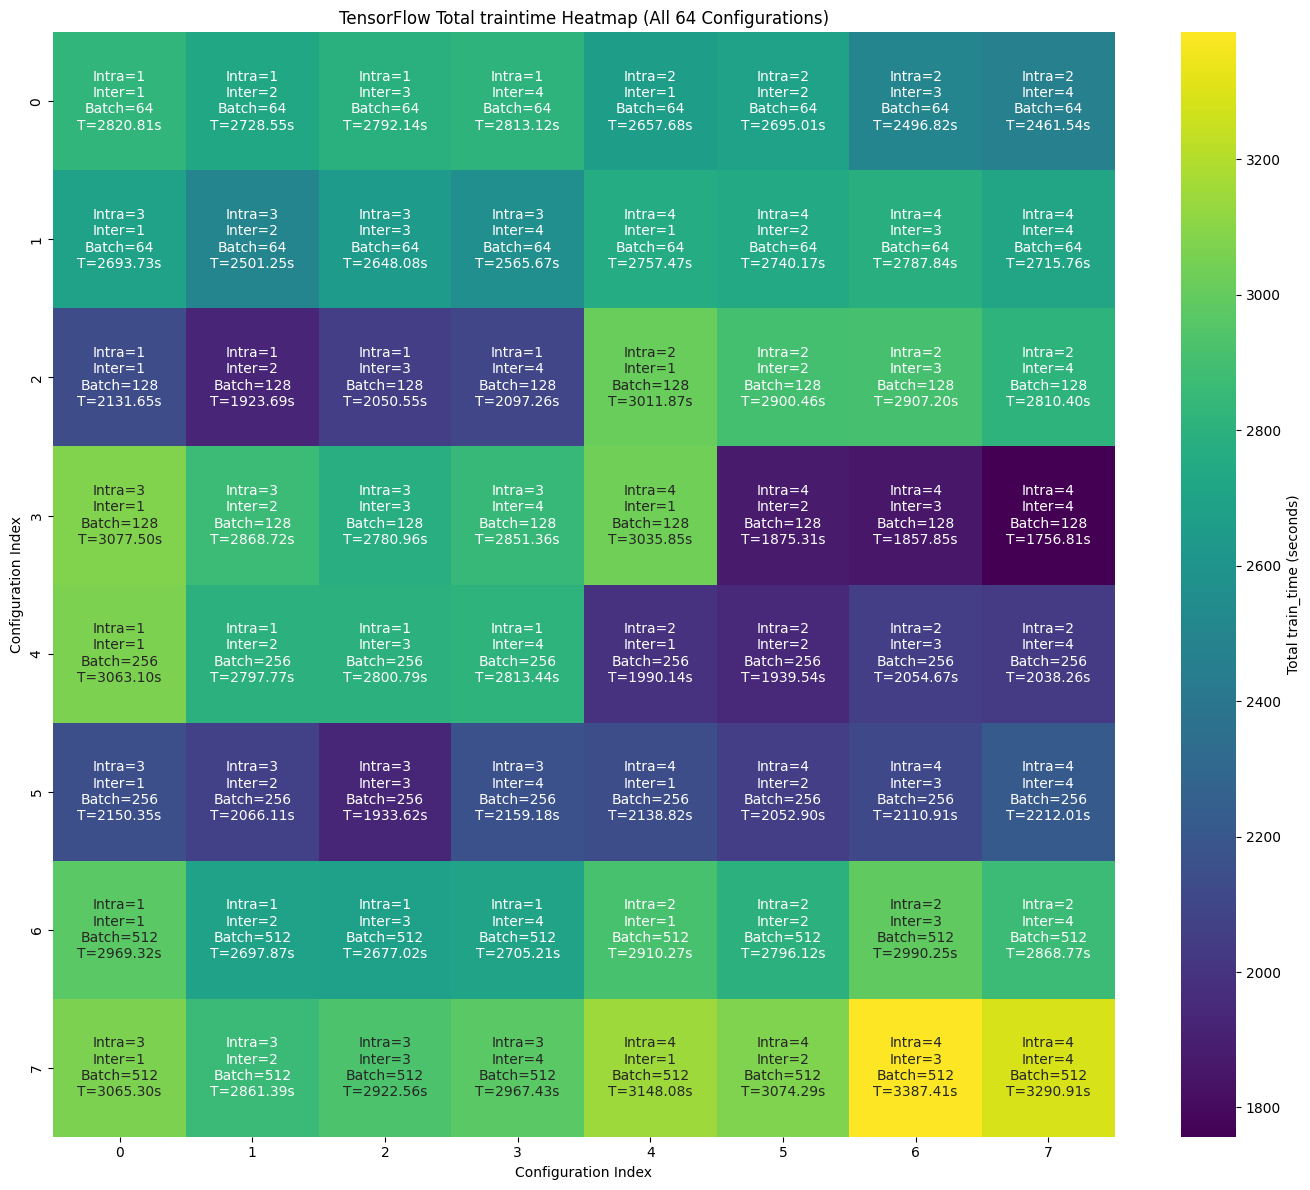

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


CSV_PATH = "/Users/akashsaha/Desktop/High-Performance-Computing/Heatmap/TensorFlow/Results/all_profiles_tf.csv"
df = pd.read_csv(CSV_PATH)


TOTAL_COL = "train_time_total_sec"   
assert TOTAL_COL in df.columns, "train_time_total_sec column not found in TF CSV"


agg = (
    df.groupby(
        ["intra_threads", "inter_threads", "batch_size"],
        as_index=False
    )[TOTAL_COL]
    .mean()
)


agg = agg.sort_values(
    by=["batch_size", "intra_threads", "inter_threads"]
).reset_index(drop=True)


assert len(agg) == 64, f"Expected 64 configs, got {len(agg)}"


heatmap_data = agg[TOTAL_COL].values.reshape(8, 8)


labels = agg.apply(
    lambda r: (
        f"Intra={int(r.intra_threads)}\n"
        f"Inter={int(r.inter_threads)}\n"
        f"Batch={int(r.batch_size)}\n"
        f"T={r[TOTAL_COL]:.2f}s"
    ),
    axis=1
).values.reshape(8, 8)


plt.figure(figsize=(14, 12))
sns.heatmap(
    heatmap_data,
    annot=labels,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "Total train_time (seconds)"}
)

plt.title("TensorFlow Total traintime Heatmap (All 64 Configurations)")
plt.xlabel("Configuration Index")
plt.ylabel("Configuration Index")
plt.tight_layout()
plt.show()